STEP 1: DATASET + DATA COLLECTION

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_mental_health.csv to student_mental_health.csv


STEP 2: DATA EXPLORATION



In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
data = pd.read_csv('student_mental_health.csv')
print("\n DATASET \n")



 DATASET 



In [ ]:
print(data.head())


  Student_ID  Age  Gender  Year_of_Study  Sleep_Hours  Study_Hours_Per_Week  \
0    STU0001   22    Male              3          6.6                  17.6   
1    STU0002   21    Male              4          5.6                  22.4   
2    STU0003   22    Male              5          7.1                  28.1   
3    STU0004   24    Male              1          4.5                  14.8   
4    STU0005   20  Female              1          6.7                  17.2   

    GPA  Social_Media_Hours  Screen_Time_Hours Physical_Activity  \
0  2.91                 6.9                7.5          Moderate   
1  2.92                 7.6               11.5               Low   
2  2.68                 6.5                8.9               Low   
3  2.23                 5.5                7.6              High   
4  2.69                 4.3                7.0          Moderate   

   Financial_Stress  Family_Support  Attendance_Rate Part_Time_Job  \
0               8.5             4.0           

In [ ]:
print("\nDataset Shape:")
print(data.shape)


Dataset Shape:
(2000, 17)


In [ ]:
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      2000 non-null   object 
 1   Age                             2000 non-null   int64  
 2   Gender                          2000 non-null   object 
 3   Year_of_Study                   2000 non-null   int64  
 4   Sleep_Hours                     1938 non-null   float64
 5   Study_Hours_Per_Week            2000 non-null   float64
 6   GPA                             1962 non-null   float64
 7   Social_Media_Hours              1942 non-null   float64
 8   Screen_Time_Hours               2000 non-null   float64
 9   Physical_Activity               2000 non-null   object 
 10  Financial_Stress                1909 non-null   float64
 11  Family_Support                  1946 non-null   float64
 12  Attendance_R

In [ ]:
print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
               Age  Year_of_Study  Sleep_Hours  Study_Hours_Per_Week  \
count  2000.000000    2000.000000  1938.000000           2000.000000   
mean     21.131500       2.630000     6.758875             19.997900   
std       2.139275       1.316802     1.127072              5.719274   
min      17.000000       1.000000     3.300000              2.400000   
25%      20.000000       1.000000     6.000000             16.000000   
50%      21.000000       2.000000     6.700000             19.800000   
75%      23.000000       4.000000     7.600000             24.000000   
max      29.000000       5.000000    10.000000             38.300000   

               GPA  Social_Media_Hours  Screen_Time_Hours  Financial_Stress  \
count  1962.000000         1942.000000        2000.000000       1909.000000   
mean      2.562503            6.013955           8.548500          5.956260   
std       0.343993            1.153422           1.657571          1.893941   
min       1.5

In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Student_ID                         0
Age                                0
Gender                             0
Year_of_Study                      0
Sleep_Hours                       62
Study_Hours_Per_Week               0
GPA                               38
Social_Media_Hours                58
Screen_Time_Hours                  0
Physical_Activity                  0
Financial_Stress                  91
Family_Support                    54
Attendance_Rate                   47
Part_Time_Job                      0
Diet_Quality                      69
Previous_Mental_Health_History     0
Mental_Health_Risk                 0
dtype: int64


In [ ]:

print("\nTarget Distribution:")
print(
    data["Mental_Health_Risk"].value_counts()
)



Target Distribution:
Mental_Health_Risk
High      680
Medium    660
Low       660
Name: count, dtype: int64


STEP 3: DATA EXPLORATION VISUALIZATION

In [ ]:
os.makedirs(
    "outputs",
    exist_ok=True
)

Mental Health Risk Distribution

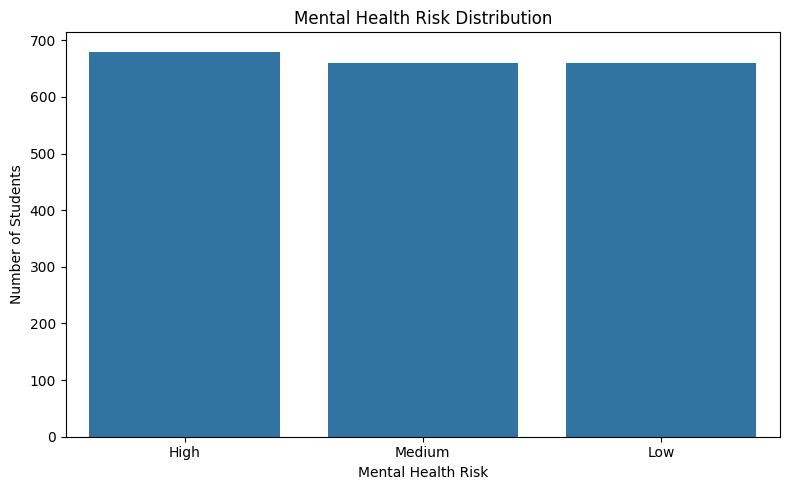

In [ ]:

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    x="Mental_Health_Risk",
    data=data
)

plt.title(
    "Mental Health Risk Distribution"
)

plt.xlabel(
    "Mental Health Risk"
)

plt.ylabel(
    "Number of Students"
)

plt.tight_layout()

plt.savefig(
    "outputs/risk_distribution.png"
)

plt.show()

Sleep Hours Analysis

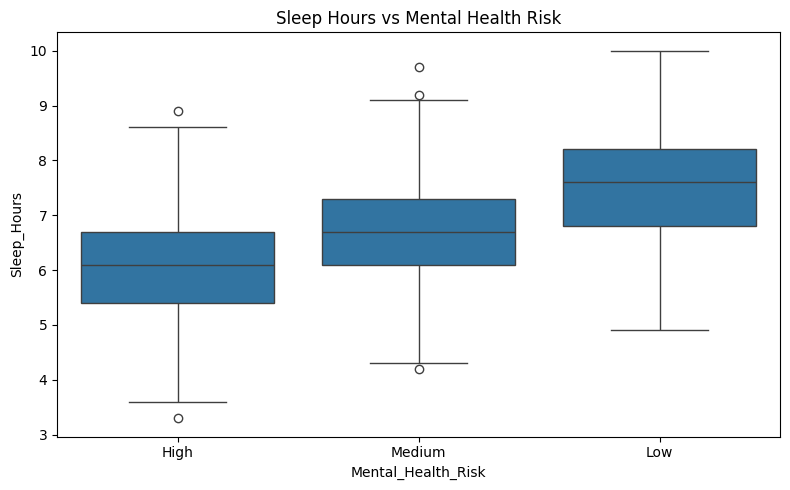

In [ ]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    x="Mental_Health_Risk",

    y="Sleep_Hours",

    data=data
)

plt.title(
    "Sleep Hours vs Mental Health Risk"
)

plt.tight_layout()

plt.savefig(
    "outputs/sleep_analysis.png"
)

plt.show()

GPA Analysis

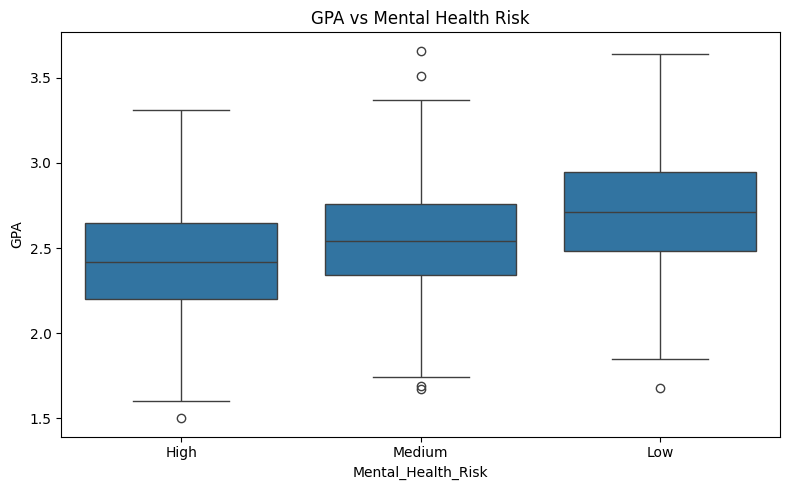

In [ ]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    x="Mental_Health_Risk",

    y="GPA",

    data=data
)

plt.title(
    "GPA vs Mental Health Risk"
)

plt.tight_layout()

plt.savefig(
    "outputs/gpa_analysis.png"
)

plt.show()

Financial Stress Analysis

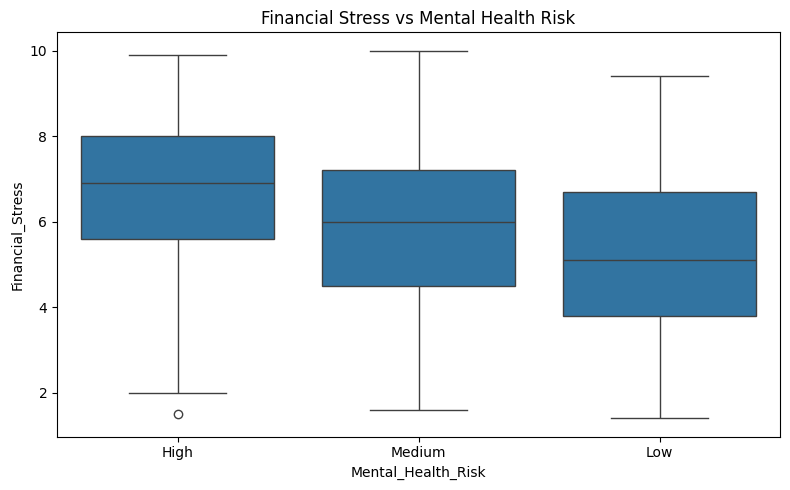

In [ ]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    x="Mental_Health_Risk",

    y="Financial_Stress",

    data=data
)

plt.title(
    "Financial Stress vs Mental Health Risk"
)

plt.tight_layout()

plt.savefig(
    "outputs/financial_stress_analysis.png"
)

plt.show()

STEP 4: CORRELATION HEATMAP

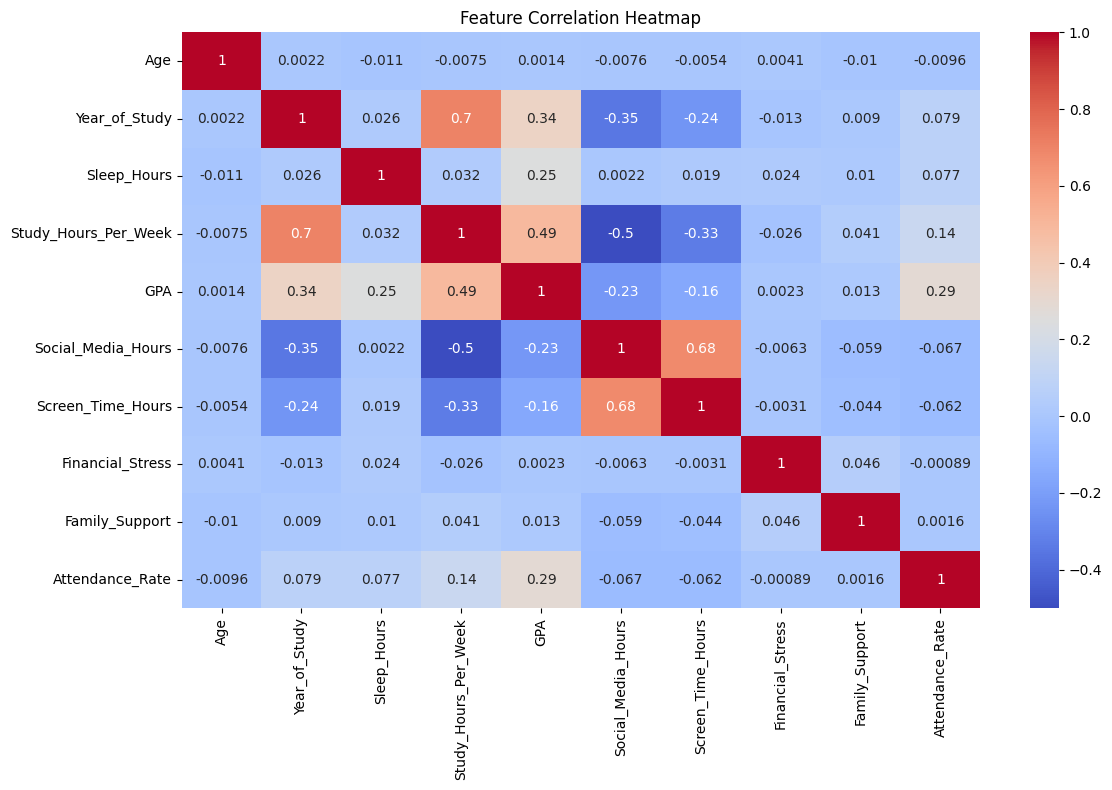

In [ ]:
numeric_data = data.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(
    figsize=(12, 8)
)

sns.heatmap(
    numeric_data.corr(),

    annot=True,

    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "outputs/correlation_heatmap.png"
)

plt.show()

STEP 5: MISSING VALUE HANDLING

In [ ]:
data = data.drop(
    "Student_ID",
    axis=1
)

In [ ]:
X = data.drop(
    "Mental_Health_Risk",
    axis=1
)

y = data[
    "Mental_Health_Risk"
]

Numerical Columns

In [ ]:
numeric_features = [
    "Age",
    "Year_of_Study",
    "Sleep_Hours",
    "Study_Hours_Per_Week",
    "GPA",
    "Social_Media_Hours",
    "Screen_Time_Hours",
    "Financial_Stress",
    "Family_Support",
    "Attendance_Rate"
]

Categorical Columns

In [ ]:
categorical_features = [
    "Gender",
    "Physical_Activity",
    "Part_Time_Job",
    "Diet_Quality",
    "Previous_Mental_Health_History"
]

STEP 6: CREATE PREPROCESSING PIPELINE

In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

Numerical Pipeline

In [ ]:
numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

Categorical Pipeline

In [ ]:
categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

Combine Both

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

STEP 7: TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

STEP 8: TRAIN MODELS

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(

                n_estimators=200,

                random_state=42
            )
        )
    ]
)

SVM

In [ ]:
from sklearn.svm import SVC

svm_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            SVC(
                probability=True,
                random_state=42
            )
        )
    ]
)

STEP 9: TEST MODELS

In [ ]:
from sklearn.metrics import accuracy_score

models = {

    "Logistic Regression":
    logistic_model,

    "KNN":
    knn_model,

    "Decision Tree":
    decision_tree_model,

    "Random Forest":
    random_forest_model,

    "SVM":
    svm_model
}

In [ ]:
results = {}

for name, model in models.items():

    print(
        f"\nTraining {name}..."
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results[name] = accuracy

    print(
        f"{name} Accuracy: {accuracy:.4f}"
    )


Training Logistic Regression...
Logistic Regression Accuracy: 0.7550

Training KNN...
KNN Accuracy: 0.5700

Training Decision Tree...
Decision Tree Accuracy: 0.5675

Training Random Forest...
Random Forest Accuracy: 0.6925

Training SVM...
SVM Accuracy: 0.7175


STEP 10: MODEL COMPARISON

In [ ]:
print(
    "\n========== MODEL COMPARISON =========="
)

for name, accuracy in results.items():

    print(

        f"{name}: "

        f"{accuracy * 100:.2f}%"
    )


========== MODEL COMPARISON ==========
Logistic Regression: 75.50%
KNN: 57.00%
Decision Tree: 56.75%
Random Forest: 69.25%
SVM: 71.75%


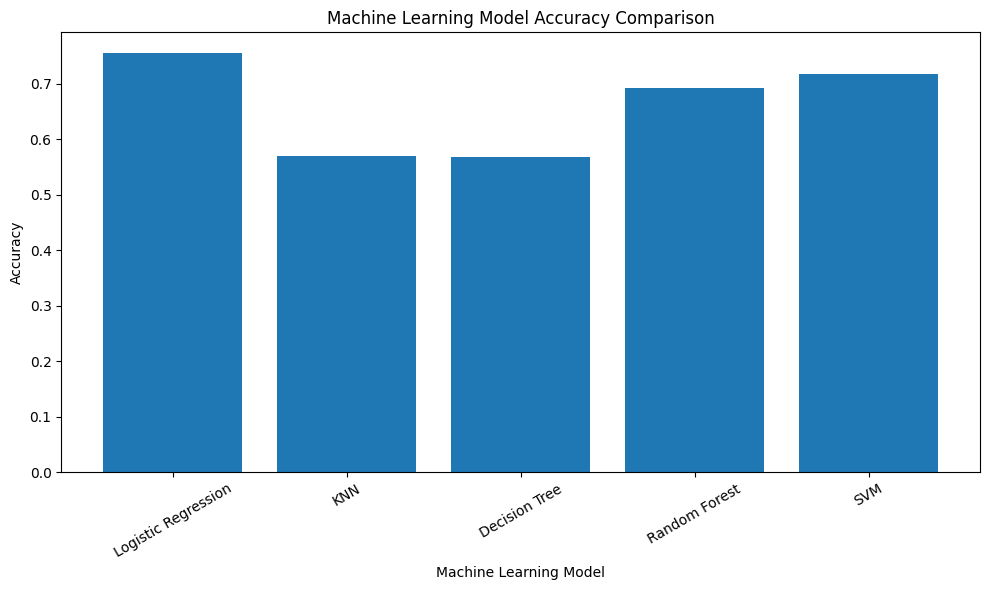

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results.keys(),
    results.values()
)

plt.title(
    "Machine Learning Model Accuracy Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.savefig(
    "outputs/model_comparison.png"
)

plt.show()

STEP 11: SELECT BEST MODEL

In [ ]:
best_model_name = max(
    results,
    key=results.get
)

best_model = models[
    best_model_name
]

print(
    "\nBest Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    results[best_model_name]
)


Best Model: Logistic Regression
Best Accuracy: 0.755


STEP 12: DETAILED MODEL EVALUATION

In [ ]:
from sklearn.metrics import (

    classification_report,

    confusion_matrix
)

Predict:

In [ ]:
best_prediction = best_model.predict(

    X_test
)

Classification report:

In [ ]:
print(

    classification_report(

        y_test,

        best_prediction
    )
)

              precision    recall  f1-score   support

        High       0.81      0.82      0.82       136
         Low       0.82      0.81      0.81       132
      Medium       0.63      0.63      0.63       132

    accuracy                           0.76       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.76      0.75       400



STEP 13: CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(

    y_test,

    best_prediction,

    labels=[

        "Low",

        "Medium",

        "High"
    ]
)

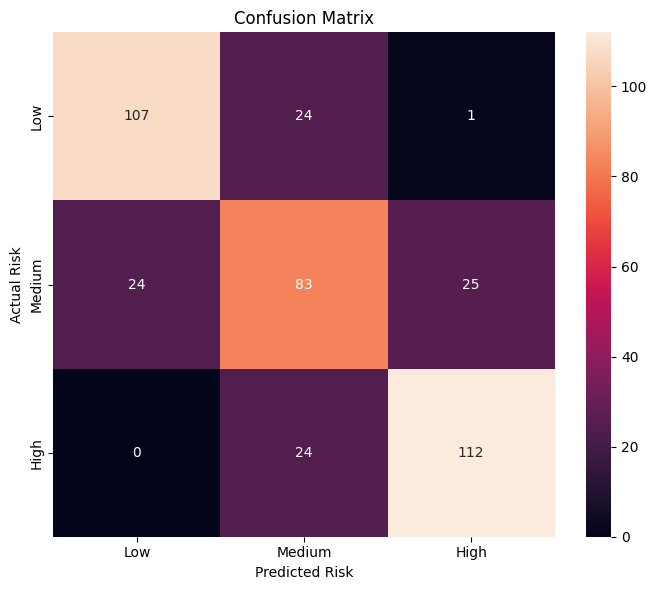

In [ ]:
plt.figure(

    figsize=(7, 6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=[

        "Low",

        "Medium",

        "High"
    ],

    yticklabels=[

        "Low",

        "Medium",

        "High"
    ]
)

plt.xlabel(

    "Predicted Risk"
)

plt.ylabel(

    "Actual Risk"
)

plt.title(

    "Confusion Matrix"
)

plt.tight_layout()

plt.savefig(

    "outputs/confusion_matrix.png"
)

plt.show()

STEP 14: SAVE TRAINED MODEL

In [ ]:
os.makedirs(

    "models",

    exist_ok=True
)

In [ ]:
import joblib

In [ ]:
joblib.dump(

    best_model,

    "models/mental_health_model.pkl"
)

['models/mental_health_model.pkl']